In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL.ImageOps import expand
from narwhals.testing import assert_frame_equal

The Netflix movies dataset(kaggle) contains 8800 unique values and 12 columns such as director, cast, data added rating, description, etc.
I am going to make my first exploratory data analysis by identifying possible insights and answering some related questions.

In [2]:
df = pd.read_csv("/home/miras/PycharmProjects/PythonProject/work/datasets/netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


1) The most of the TV show's "director" column is missing,
 2) the "data added" column should be converted to the date format,
   3) looks like that the values of "cast" columns is missing at random, so I will just drop them
   4) the missing country values could be filled by some RNN using the cast column to identify their most likely nation, but I will not dip too much for my first work


Here I dropped the missing movie directors, because it will not cost too much,
but the tv shows will cost, so they will stay

In [5]:
df[df["type"]=="Movie"]["director"].isna().value_counts()

director
False    5943
True      188
Name: count, dtype: int64

In [6]:
mask = (df["type"]=="Movie") & (df["director"].isna())
df = df[~mask]

In [7]:
df[df["type"]!="Movie"]["director"].isna().value_counts()

director
True     2446
False     230
Name: count, dtype: int64

In [8]:
df["director"]=df["director"].fillna("Unknown")

Dropping missing values and converting to date format



In [9]:
df["date_added"] = pd.to_datetime(df["date_added"], format="%B %d, %Y", errors="coerce")

In [10]:
df = df.dropna(subset=["cast", "country","date_added", "rating", "duration"])

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 7121 entries, 1 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7121 non-null   str           
 1   type          7121 non-null   str           
 2   title         7121 non-null   str           
 3   director      7121 non-null   str           
 4   cast          7121 non-null   str           
 5   country       7121 non-null   str           
 6   date_added    7121 non-null   datetime64[us]
 7   release_year  7121 non-null   int64         
 8   rating        7121 non-null   str           
 9   duration      7121 non-null   str           
 10  listed_in     7121 non-null   str           
 11  description   7121 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 723.2 KB


Lets answer some basic questions like what is the most popular rating

In [12]:
df['rating'].value_counts().sort_values(ascending=False).head(1)

rating
TV-MA    2601
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='rating'>

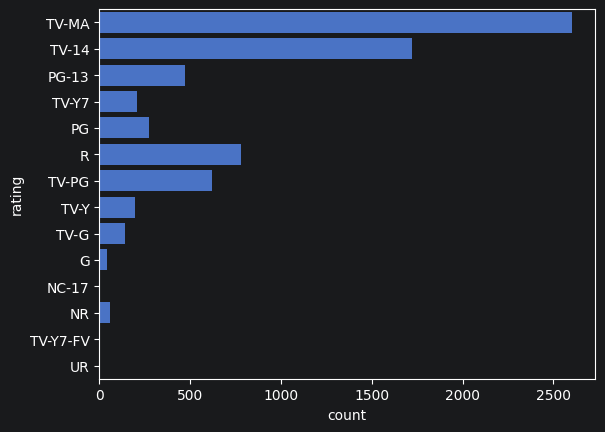

In [13]:
sns.countplot(df["rating"])

We see here that the mature content is the most popular, then lets answer which county produces the most of this type

In [14]:
df[df["rating"]=="TV-MA"]["country"].value_counts().sort_values(ascending=False).head(3)

country
United States     757
India             237
United Kingdom    137
Name: count, dtype: int64

US is the leader in MA movies

In [15]:
df["country"].value_counts().sort_values(ascending=False).head(3)

country
United States     2407
India              929
United Kingdom     326
Name: count, dtype: int64

US is also the leader in the number of all films, now lets see the productions of main countries over each year

In [16]:
top_countries = df["country"].value_counts().head(5).index

In [17]:
df_top = df[df["country"].isin(top_countries)]

In [18]:
grouped = df_top.groupby(["release_year", "country"]).size().reset_index(name="count")

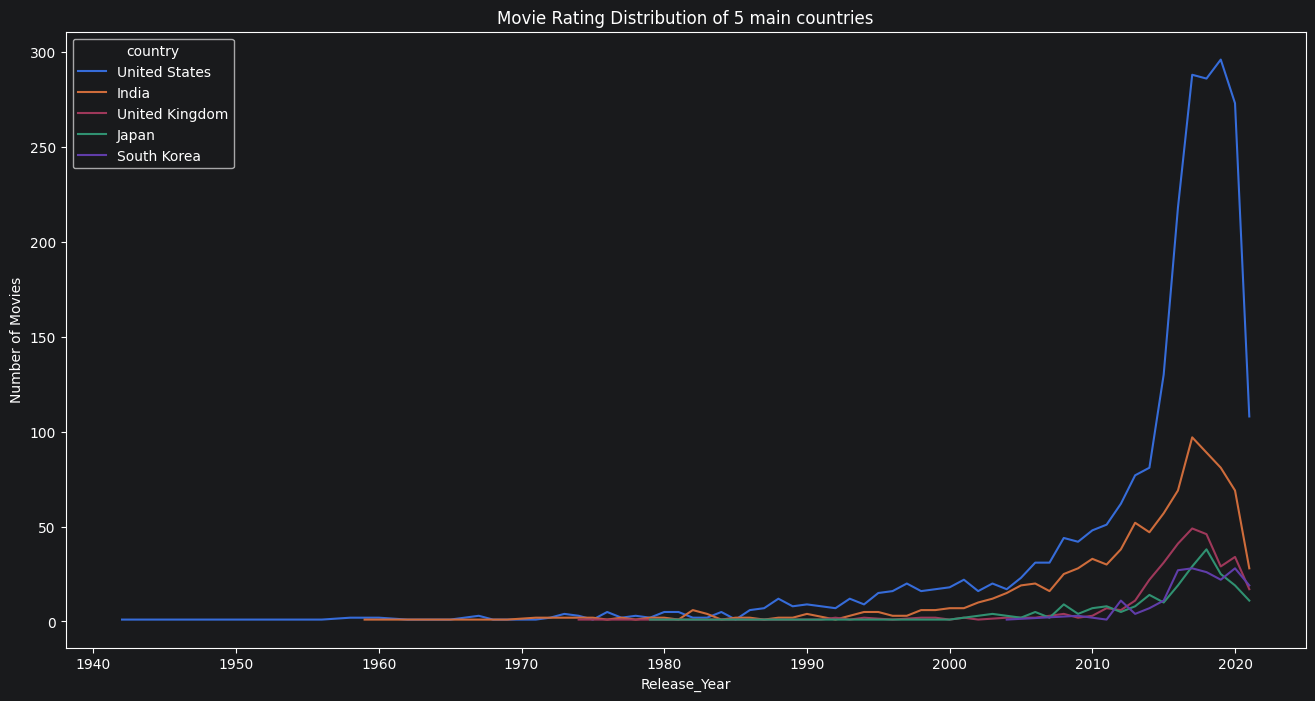

In [19]:
plt.figure(figsize=(16,8))
sns.lineplot(x="release_year", y="count", data=grouped, hue="country")
plt.title("Movie Rating Distribution of 5 main countries")
plt.xlabel("Release_Year")
plt.ylabel("Number of Movies")
plt.show()

The noticeable thing is that all films had a big rise from 2012 to 2017 approximately, then dropped a lot.

Lets divide the duration column to two separate columns to make easier for analysing

In [20]:
df["Numbers"] = df["duration"].str.split(" ", expand=True)[0].astype(float)

In [21]:
df["Number_of_mins"] = df.loc[df["type"]=="Movie", "Numbers"].astype(int)

In [22]:
df["Number_of_seasons"] = df.loc[df["type"]=="TV Show", "Numbers"].astype(int)

Then we can see the rating of longest and shortest movies and seasons

In [23]:
df.sort_values("Number_of_mins", ascending=False)[["title","Number_of_mins"]].head()

,title,Number_of_mins
2491,The School of Mischief,253.0
2487,No Longer kids,237.0
166,Once Upon a Time in America,229.0
7932,Sangam,228.0
1019,Lagaan,224.0


In [24]:
df.sort_values("Number_of_mins")[["title","Number_of_mins"]].head()

,title,Number_of_mins
1484,Cops and Robbers,8.0
4707,Zion,12.0
3775,Cosmos Laundromat: First Cycle,12.0
694,Aziza,13.0
5375,Buddy Thunderstruck: The Maybe Pile,14.0


In [25]:
df.sort_values("Number_of_seasons", ascending=False)[["title","Number_of_seasons"]].head()

,title,Number_of_seasons
548,Grey's Anatomy,17.0
2423,Supernatural,15.0
4798,NCIS,15.0
1354,Heartland,13.0
4220,COMEDIANS of the world,13.0


In [26]:
df.sort_values("Number_of_seasons")[["title","Number_of_seasons"]].head()

,title,Number_of_seasons
111,Sharkdog,1.0
120,Heroes of Goo Jit Zu,1.0
125,Q-Force,1.0
8720,What Happens to My Family,1.0
8721,What Is Love?,1.0


and the mean value

In [27]:
df["Number_of_mins"].mean()

np.float64(102.70144648023144)

In [28]:
df["Number_of_seasons"].mean()

np.float64(1.8326446280991735)

Lets analyze which genre appears the most

In [29]:
df["listed_in"] = df["listed_in"].str.split(", ")

In [30]:
df_genres = df.explode(
    "listed_in"
)

In [31]:
df_genres["listed_in"].value_counts()

listed_in
International Movies            2369
Dramas                          2293
Comedies                        1553
International TV Shows          1027
Action & Adventure               806
Independent Movies               740
TV Dramas                        634
Romantic Movies                  579
Thrillers                        547
Children & Family Movies         503
TV Comedies                      457
Documentaries                    391
Crime TV Shows                   349
Horror Movies                    336
Kids' TV                         330
Stand-Up Comedy                  294
Music & Musicals                 292
Romantic TV Shows                289
Sci-Fi & Fantasy                 236
British TV Shows                 185
Sports Movies                    156
Docuseries                       153
Anime Series                     148
TV Action & Adventure            144
Spanish-Language TV Shows        134
Reality TV                       133
Korean TV Shows             

The same with actors

In [32]:
df["cast"] = df["cast"].str.split(", ")

In [33]:
df_actors = df.explode(
    "cast"
)

In [34]:
df_actors["cast"].value_counts()

cast
Anupam Kher              43
Shah Rukh Khan           34
Naseeruddin Shah         31
Akshay Kumar             30
Om Puri                  30
                         ..
Ryan Newman               1
Raaghav Chanana           1
Malkeet Rauni             1
Anita Shabdish            1
Chittaranjan Tripathy     1
Name: count, Length: 33886, dtype: int64